<a href="https://colab.research.google.com/github/shamilps07-sys/ict_assignments/blob/main/Assignment_2_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''
Analyze Olympic medal data using Pandas, Matplotlib, and Seaborn to discover trends and insights.
You are given a dataset: athlete_events.csv
The dataset contains:
Name
Sex
Age
Team
Year
City
Sport
Event
Medal (Gold / Silver / Bronze / NaN)
'''

'\nAnalyze Olympic medal data using Pandas, Matplotlib, and Seaborn to discover trends and insights.\nYou are given a dataset: athlete_events.csv\nThe dataset contains:\nName\nSex\nAge\nTeam\nYear\nCity\nSport\nEvent\nMedal (Gold / Silver / Bronze / NaN)\n'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#first 5 datas
auto_data = pd.read_csv('/content/athlete_events - medal (1).csv')
auto_data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [ ]:
display(auto_data.head())
print(f"Number of rows: {auto_data.shape[0]}")
print(f"Number of columns: {auto_data.shape[1]}")
print("Column names:")
for col in auto_data.columns:
    print(col)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Number of rows: 246864
Number of columns: 15
Column names:
ID
Name
Sex
Age
Height
Weight
Team
NOC
Games
Year
Season
City
Sport
Event
Medal


In [ ]:
data.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [ ]:
numerical_cols = auto_data.select_dtypes(include=['number']).columns.tolist()
categorical_cols = auto_data.select_dtypes(exclude=['number']).columns.tolist()

print("\nNumerical columns:")
for col in numerical_cols:
    print(col)

print("\nCategorical columns:")
for col in categorical_cols:
    print(col)


Numerical columns:
ID
Age
Height
Weight
Year

Categorical columns:
Name
Sex
Team
NOC
Games
Season
City
Sport
Event
Medal


In [ ]:
print('Number of missing values per column:')
display(auto_data.isnull().sum())

Number of missing values per column:


,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [ ]:
medal_winners = auto_data.dropna(subset=['Medal'])
display(medal_winners.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


In [ ]:
total_medals_per_country = medal_winners['NOC'].value_counts().reset_index()
total_medals_per_country.columns = ['NOC', 'Medal_Count']

display(total_medals_per_country.head(10))

,NOC,Medal_Count
0,USA,5161
1,URS,2271
2,GBR,1904
3,GER,1883
4,FRA,1714
5,ITA,1530
6,SWE,1433
7,CAN,1239
8,AUS,1219
9,HUN,1048


/tmp/ipykernel_193/4117670896.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NOC', y='Medal_Count', data=total_medals_per_country.head(10), palette='viridis')


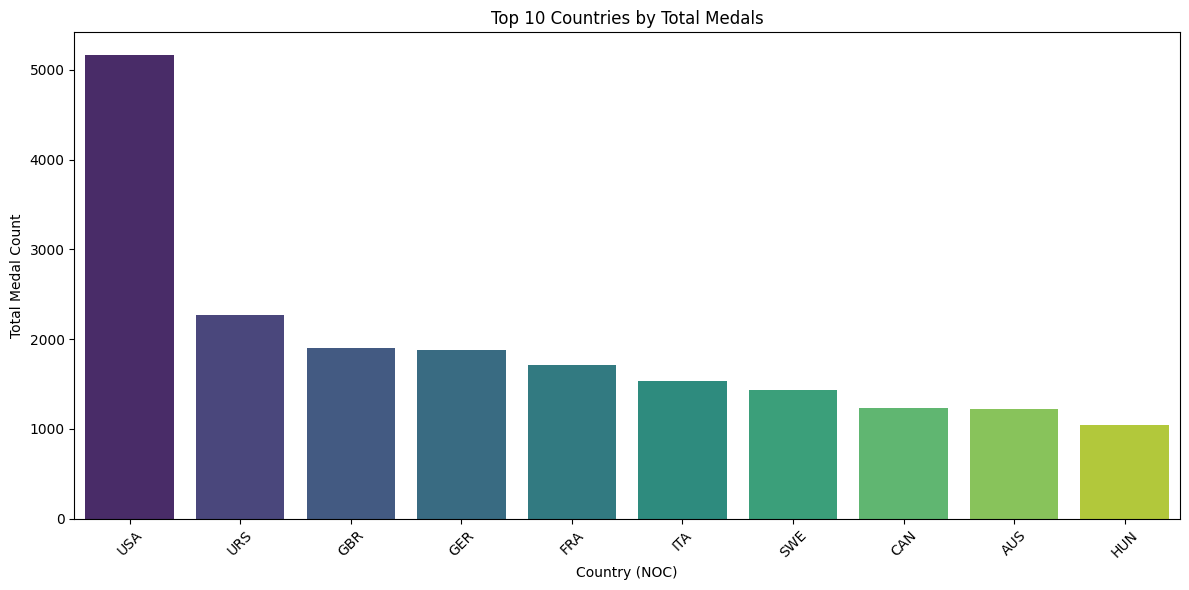

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='NOC', y='Medal_Count', data=total_medals_per_country.head(10), palette='viridis')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Medal Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Countries by Gold Medals:


,NOC,Gold_Medal_Count
0,USA,2400
1,URS,985
2,GER,643
3,GBR,627
4,ITA,532
5,FRA,488
6,SWE,441
7,CAN,430
8,HUN,402
9,NOR,370


/tmp/ipykernel_193/1157984202.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NOC', y='Gold_Medal_Count', data=total_gold_medals_per_country.head(10), palette='YlOrBr') # Changed 'Gold' to 'YlOrBr'


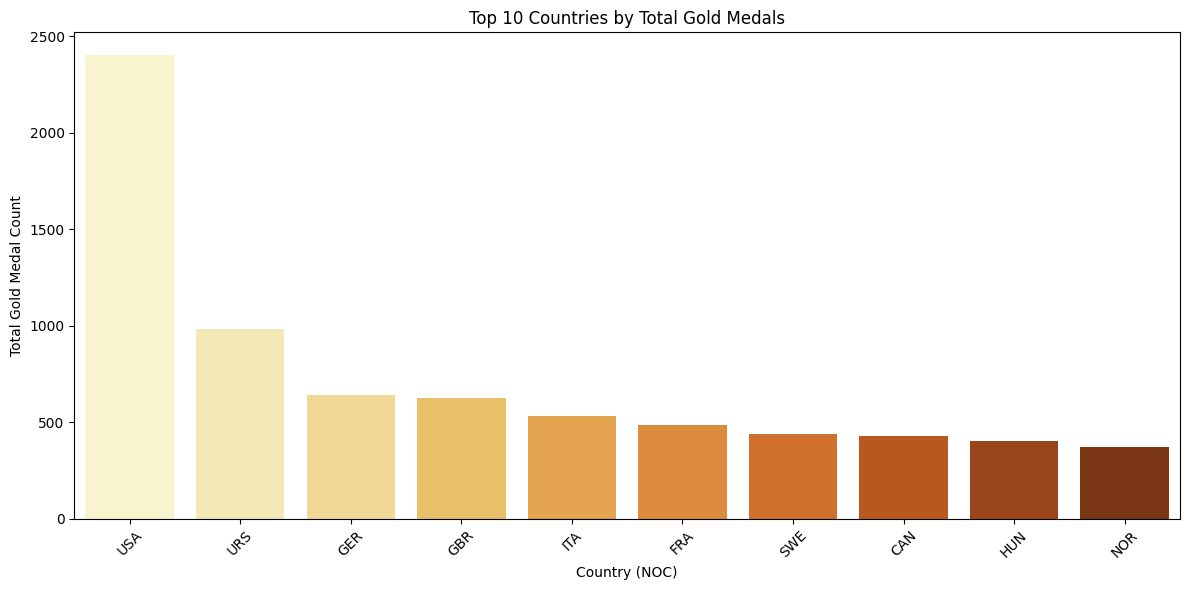

In [ ]:
gold_medal_winners = medal_winners[medal_winners['Medal'] == 'Gold']
total_gold_medals_per_country = gold_medal_winners['NOC'].value_counts().reset_index()
total_gold_medals_per_country.columns = ['NOC', 'Gold_Medal_Count']
print('Top 10 Countries by Gold Medals:')
display(total_gold_medals_per_country.head(10))
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x='NOC', y='Gold_Medal_Count', data=total_gold_medals_per_country.head(10), palette='YlOrBr') # Changed 'Gold' to 'YlOrBr'
plt.title('Top 10 Countries by Total Gold Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Gold Medal Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Total Medals Won by Gender:


,Sex,Medal_Count
0,M,25972
1,F,9984


/tmp/ipykernel_193/2700824517.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Medal_Count', data=gender_medal_counts, palette='Paired')


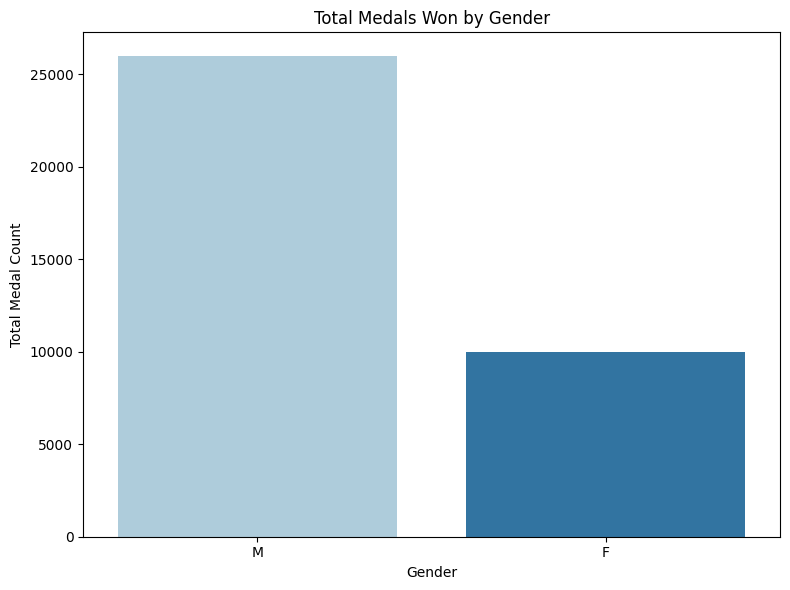

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
gender_medal_counts = medal_winners['Sex'].value_counts().reset_index()
gender_medal_counts.columns = ['Sex', 'Medal_Count']
print('Total Medals Won by Gender:')
display(gender_medal_counts)
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex', y='Medal_Count', data=gender_medal_counts, palette='Paired')
plt.title('Total Medals Won by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Medal Count')
plt.tight_layout()
plt.show()

Medal Trend Over Years by Gender:


,Year,Sex,Medal_Count
0,1896.0,M,129
1,1900.0,F,12
2,1900.0,M,543
3,1904.0,F,9
4,1904.0,M,422


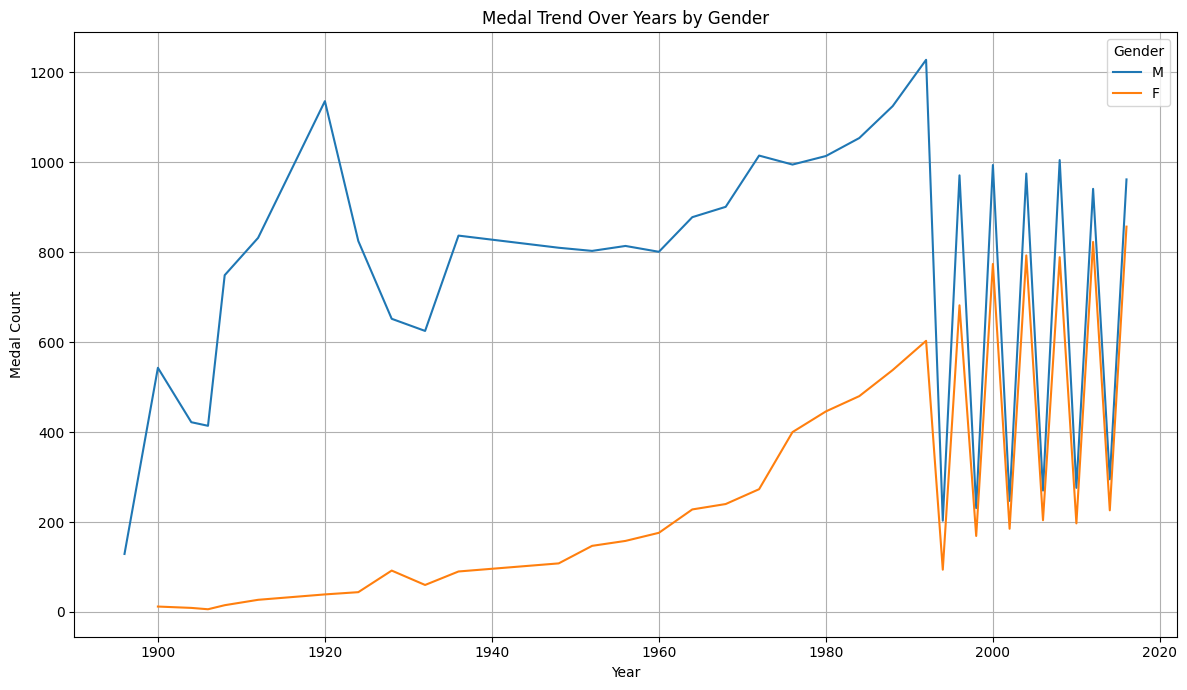

In [ ]:
gender_year_medals = medal_winners.groupby(['Year', 'Sex'])['Medal'].count().reset_index()
gender_year_medals.columns = ['Year', 'Sex', 'Medal_Count']
print('Medal Trend Over Years by Gender:')
display(gender_year_medals.head())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.lineplot(x='Year', y='Medal_Count', hue='Sex', data=gender_year_medals)
plt.title('Medal Trend Over Years by Gender')
plt.xlabel('Year')
plt.ylabel('Medal Count')
plt.legend(title='Gender')
plt.grid(True)
plt.tight_layout()
plt.show()

Top 10 Sports by Total Medals:


,Sport,Medal_Count
0,Athletics,3654
1,Swimming,2717
2,Rowing,2683
3,Gymnastics,2049
4,Fencing,1599
5,Football,1439
6,Ice Hockey,1414
7,Hockey,1366
8,Wrestling,1178
9,Cycling,1131


/tmp/ipykernel_193/570581794.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sport', y='Medal_Count', data=top_10_sports, palette='viridis')


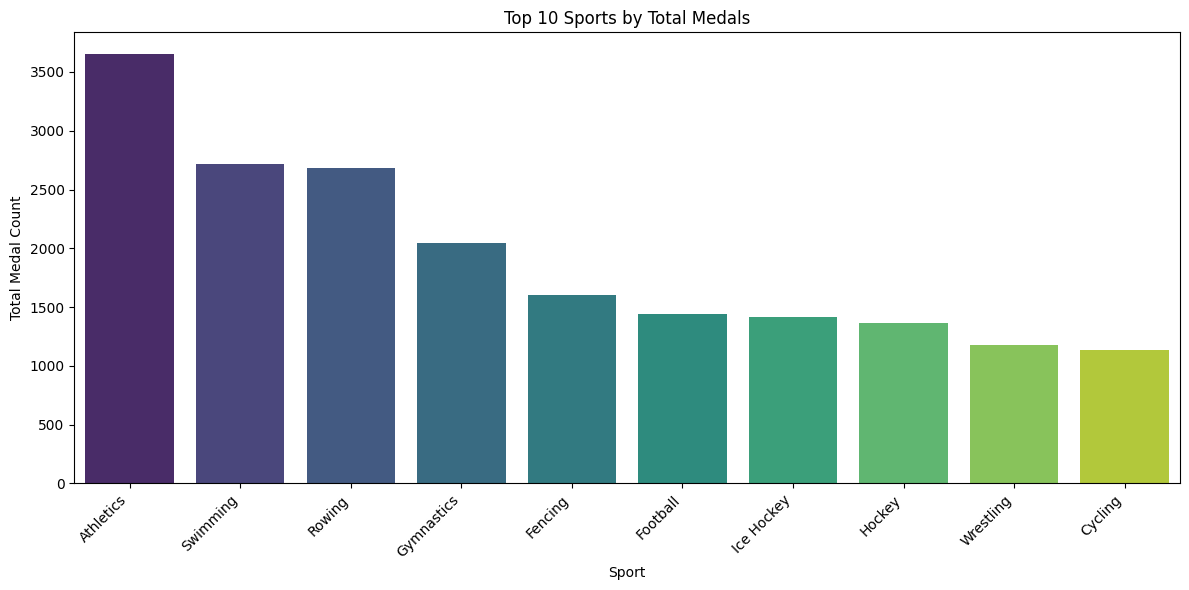

In [ ]:
top_10_sports = medal_winners['Sport'].value_counts().reset_index()
top_10_sports.columns = ['Sport', 'Medal_Count']
top_10_sports = top_10_sports.sort_values(by='Medal_Count', ascending=False).head(10)

print('Top 10 Sports by Total Medals:')
display(top_10_sports)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Sport', y='Medal_Count', data=top_10_sports, palette='viridis')
plt.title('Top 10 Sports by Total Medals')
plt.xlabel('Sport')
plt.ylabel('Total Medal Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Total Medals per Year:


,Year,Medal_Count
0,1896.0,129
1,1900.0,555
2,1904.0,431
3,1906.0,420
4,1908.0,764


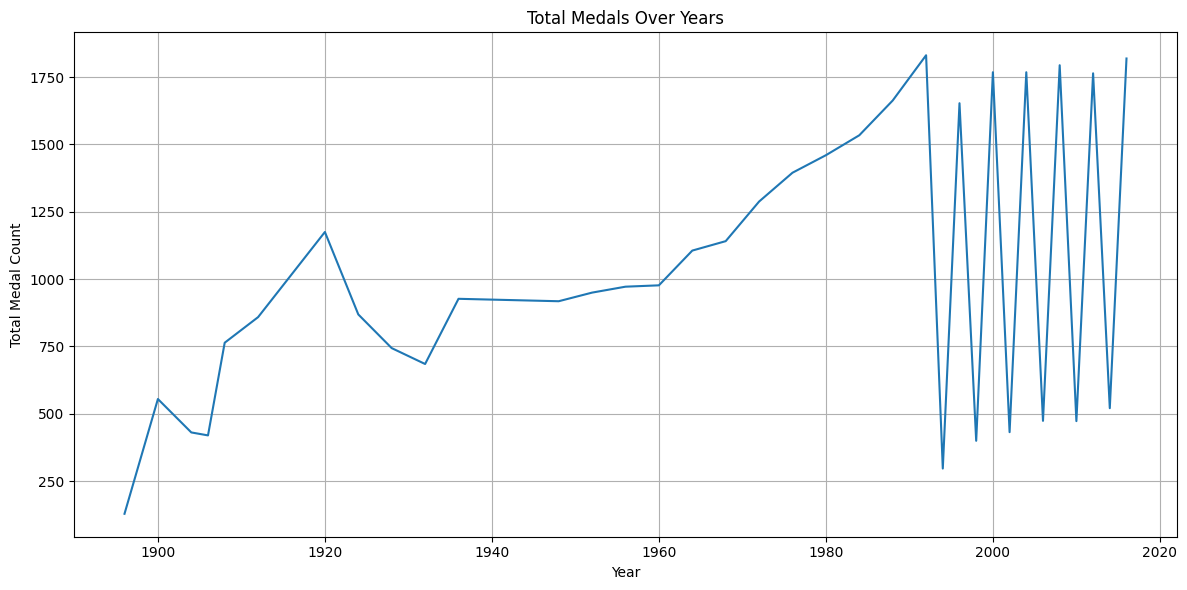

In [ ]:
total_medals_per_year = medal_winners.groupby('Year')['Medal'].count().reset_index()
total_medals_per_year.columns = ['Year', 'Medal_Count']

print('Total Medals per Year:')
display(total_medals_per_year.head())

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Medal_Count', data=total_medals_per_year)
plt.title('Total Medals Over Years')
plt.xlabel('Year')
plt.ylabel('Total Medal Count')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
highest_medal_year = total_medals_per_year.sort_values(by='Medal_Count', ascending=False).iloc[0]

print(f"The year with the highest number of medals awarded was {highest_medal_year['Year']} with {highest_medal_year['Medal_Count']} medals.")

The year with the highest number of medals awarded was 1992.0 with 1831.0 medals.


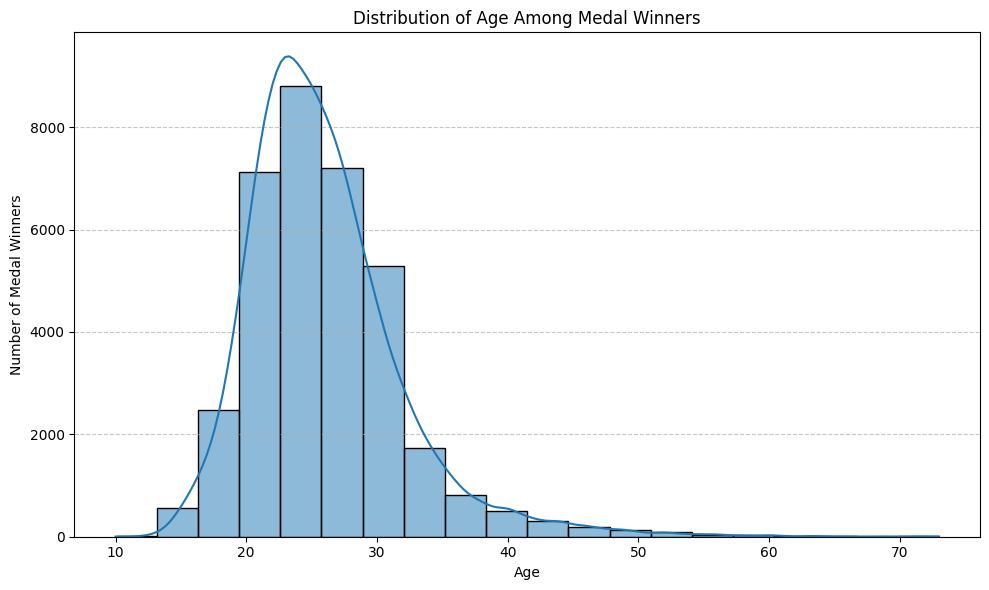

Frequency of ages (in 5-year bins):


,count
"(9.999, 15.0]",263
"(15.0, 20.0]",4598
"(20.0, 25.0]",14115
"(25.0, 30.0]",10409
"(30.0, 35.0]",3810
"(35.0, 40.0]",1180
"(40.0, 45.0]",516
"(45.0, 50.0]",247
"(50.0, 55.0]",99



The most common winning age range is: (20.0, 25.0]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(medal_winners['Age'].dropna(), bins=20, kde=True)
plt.title('Distribution of Age Among Medal Winners')
plt.xlabel('Age')
plt.ylabel('Number of Medal Winners')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
age_counts = medal_winners['Age'].value_counts(bins=range(10, 60, 5)).sort_index()
print("Frequency of ages (in 5-year bins):")
display(age_counts)
most_common_age_range = age_counts.idxmax()
print(f"\nThe most common winning age range is: {most_common_age_range}")

Average Age for Each Medal Type:


,Medal,Average_Age
0,Bronze,25.902074
1,Gold,25.906690
2,Silver,26.027022


/tmp/ipykernel_193/2598733421.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Medal', y='Average_Age', data=average_age_by_medal, palette='coolwarm')


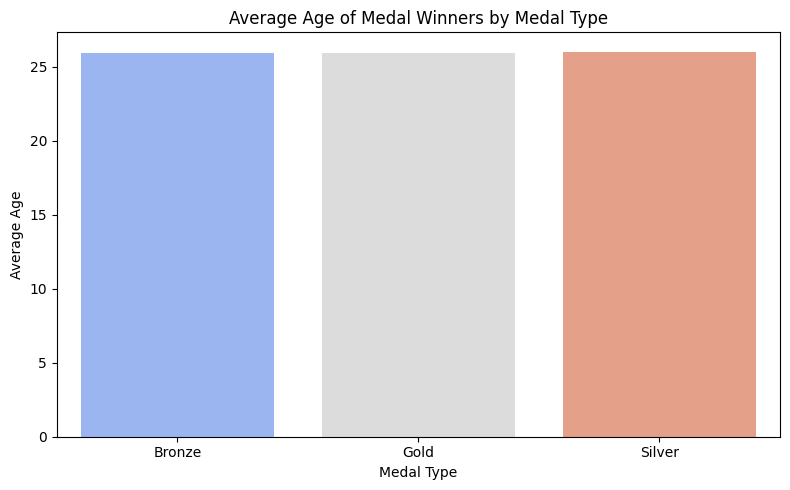

In [ ]:
average_age_by_medal = medal_winners.groupby('Medal')['Age'].mean().reset_index()
average_age_by_medal.columns = ['Medal', 'Average_Age']

print('Average Age for Each Medal Type:')
display(average_age_by_medal)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Medal', y='Average_Age', data=average_age_by_medal, palette='coolwarm')
plt.title('Average Age of Medal Winners by Medal Type')
plt.xlabel('Medal Type')
plt.ylabel('Average Age')
plt.tight_layout()
plt.show()

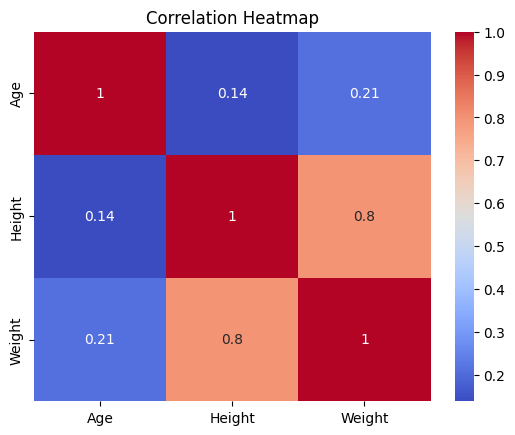

In [ ]:
df = pd.read_csv("/content/athlete_events - medal (1).csv")

# Select numerical columns
data = df[['Age', 'Height', 'Weight']]

# Compute correlation
corr = data.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

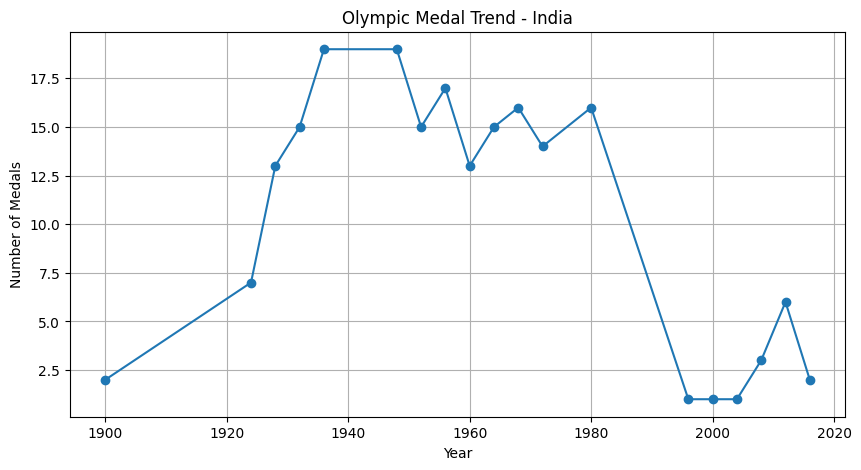

In [ ]:
# Read CSV file
df = pd.read_csv("/content/athlete_events - medal (1).csv")

# Choose a country (example: India)
country = df[df['Team'] == 'India']

# Count medals per year (excluding NaN)
medals_per_year = country.dropna(subset=['Medal']).groupby('Year')['Medal'].count()

# Plot using matplotlib
plt.figure(figsize=(10,5))
plt.plot(medals_per_year.index, medals_per_year.values, marker='o')

plt.title("Olympic Medal Trend - India")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.grid(True)

plt.show()

Dominant Country: United States
Average Age of Winners: 25.02009911894273


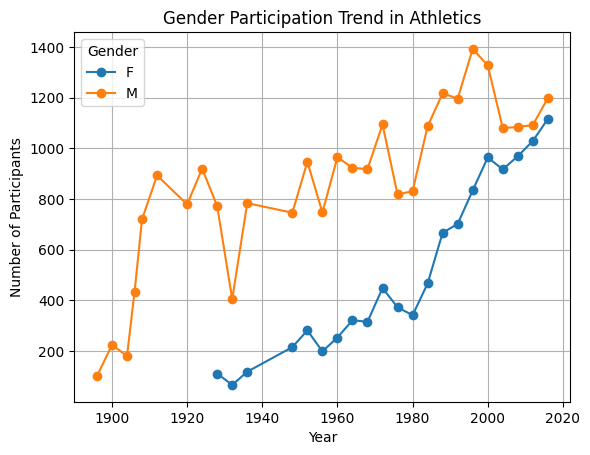

In [ ]:
# Read dataset
df = pd.read_csv("/content/athlete_events - medal (1).csv")

# Choose sport
sport_data = df[df['Sport'] == 'Athletics']

# 1. Find dominant country
country_medals = sport_data.groupby('Team')['Medal'].count()
top_country = country_medals.idxmax()
print("Dominant Country:", top_country)

# 2. Average age of winners
winners = sport_data.dropna(subset=['Medal'])
avg_age = winners['Age'].mean()
print("Average Age of Winners:", avg_age)

# 3. Gender participation trend
gender_trend = sport_data.groupby(['Year', 'Sex']).size().unstack()

# Plot graph
gender_trend.plot(kind='line', marker='o')

plt.title("Gender Participation Trend in Athletics")
plt.xlabel("Year")
plt.ylabel("Number of Participants")
plt.legend(title="Gender")
plt.grid(True)

plt.show()

In [ ]:
df = pd.read_csv("/content/athlete_events - medal (1).csv")

# Filter only gold medal winners
gold_winners = df[df['Medal'] == 'Gold']

# Sort by Age in ascending order and pick top 5
youngest_gold = gold_winners.sort_values('Age').head(5)

# Display relevant columns
print(youngest_gold[['Name', 'Age', 'Team', 'Sport', 'Event']])

                                      Name   Age           Team  \
78544         Marjorie Gestring (-Redlick)  13.0  United States   
73581                           Fu Mingxia  13.0          China   
52010   Donna Elizabeth de Varona (-Pinto)  13.0  United States   
200704       Aileen Muriel Riggin (-Soule)  13.0  United States   
119277                          Kim Yun-Mi  13.0    South Korea   

                            Sport  \
78544                      Diving   
73581                      Diving   
52010                    Swimming   
200704                     Diving   
119277  Short Track Speed Skating   

                                                    Event  
78544                          Diving Women's Springboard  
73581                             Diving Women's Platform  
52010     Swimming Women's 4 x 100 metres Freestyle Relay  
200704                         Diving Women's Springboard  
119277  Short Track Speed Skating Women's 3,000 metres...  


In [ ]:
# Read dataset
df = pd.read_csv("/content/athlete_events - medal (1).csv")

# Remove rows without medals
medal_data = df.dropna(subset=['Medal'])

# Total medals per country
total_medals = medal_data.groupby('Team')['Medal'].count()

# Gold medals per country
gold_medals = medal_data[medal_data['Medal'] == 'Gold'].groupby('Team')['Medal'].count()

# Merge into a single DataFrame
medal_ratio = pd.DataFrame({
    'Total': total_medals,
    'Gold': gold_medals
})

# Calculate Gold / Total ratio
medal_ratio['Gold_Ratio'] = medal_ratio['Gold'] / medal_ratio['Total']

# Top 5 countries by total medals
top5 = medal_ratio.sort_values('Total', ascending=False).head(5)

print(top5[['Gold', 'Total', 'Gold_Ratio']])

                 Gold  Total  Gold_Ratio
Team                                    
United States  2264.0   4793    0.472356
Soviet Union    965.0   2226    0.433513
Germany         586.0   1723    0.340104
Great Britain   477.0   1545    0.308738
France          442.0   1497    0.295257
